# **Project Name**
## Amazon Prime Video Content Analysis – Exploratory Data Analysis

# **Project Type**
## EDA (Exploratory Data Analysis)

# **Contribution**
## Individual

# **Name**
## Shiwangi

# **Project Summary**
This project focuses on performing Exploratory Data Analysis (EDA) on Amazon Prime Video TV shows and movies to understand the composition, characteristics, quality, popularity, and evolution of the platform's content library. The analysis uses a dataset containing information about more than 9,000 unique titles, along with extensive cast and director information. The dataset includes both categorical and numerical attributes such as content type, release year, age certification, runtime, genres, production countries, number of seasons, IMDb ratings, IMDb votes, TMDB popularity, and TMDB scores.

The primary objective of the project is to transform the available raw data into meaningful business insights that can support content-related decision making. The analysis begins with data exploration and cleaning, including understanding the structure of the dataset, identifying missing or null values, examining data types, and preparing the variables for analysis. Appropriate handling of missing values and data-quality issues is performed before visualization and interpretation.

Univariate analysis is used to understand the individual distributions of important variables such as content type, release year, runtime, age certification, genres, production countries, TMDB popularity, TMDB score, and weighted IMDb rating. These visualizations help identify the dominant content categories, common runtime ranges, major production markets, audience classifications, and overall rating and popularity patterns.

Bivariate and multivariate analysis is then performed to investigate relationships between important business variables. Particular attention is given to the relationship between TMDB popularity, TMDB score, and weighted IMDb rating, as these measures provide useful perspectives on content reach and perceived quality. The analysis also examines how content characteristics and ratings vary across content types, release years, and other relevant categories.

The findings from these analyses can help stakeholders understand which types of content are more prominent on the platform, how the content library has evolved over time, and how popularity relates to audience ratings. Genre and regional analysis can provide additional insights into content diversity and potential market opportunities.

Overall, the project demonstrates how data analysis and visualization can be used to convert a large streaming-content dataset into actionable insights. The results can support content acquisition, content investment, audience targeting, regional expansion, and strategic planning. The project also emphasizes clear visualization, statistical reasoning, and business-oriented interpretation rather than simply presenting descriptive statistics.

# **GitHub link**
## [link](c:/Users/veena/Downloads/labmentix_project_1.ipynb)

# **Problem Statement**
Amazon Prime Video has a large and diverse collection of TV shows and movies. Understanding the characteristics and performance of this content is important for making effective content and business decisions.

The objective of this project is to analyze the Amazon Prime Video content dataset and identify meaningful patterns related to content diversity, content type, genres, production regions, release trends, audience certification, runtime, ratings, and popularity.

The analysis aims to answer key questions such as:

1. What types of content dominate the Amazon Prime Video library?
2. Which genres are most common on the platform?
3. How has the content library evolved over different release years?
4. Which production countries contribute the most content?
5. How are titles distributed across different age certifications?
6. What is the relationship between content popularity and audience ratings?
7. How do TMDB scores and weighted IMDb ratings reflect content quality?
8. Are there identifiable patterns that can help stakeholders make better content investment and audience-targeting decisions?

# **Business Objective**
The business objective is to analyze Amazon Prime Video's content library and generate actionable insights that can support content acquisition, content investment, audience targeting, and regional content strategy.

The analysis aims to identify dominant content categories and genres, understand changes in the content library over time, evaluate content quality using TMDB and weighted IMDb ratings, examine popularity patterns, and identify potential opportunities for improving content diversity and strategic decision making.

The findings can help stakeholders understand audience-oriented content patterns and make more informed decisions regarding which types of content, genres, regions, and audience categories may deserve greater attention.

# **Data Cleaning**

In [4]:
#import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ast import literal_eval

In [5]:
#loading data 1 i.e credits.csv
df1= pd.read_csv("credits.csv")
df1

,person_id,id,name,character,role
0,59401,ts20945,Joe Besser,Joe,ACTOR
1,31460,ts20945,Moe Howard,Moe,ACTOR
2,31461,ts20945,Larry Fine,Larry,ACTOR
3,21174,tm19248,Buster Keaton,Johnny Gray,ACTOR
4,28713,tm19248,Marion Mack,Annabelle Lee,ACTOR
...,...,...,...,...,...
124230,1938589,tm1054116,Sangam Shukla,Madhav,ACTOR
124231,1938565,tm1054116,Vijay Thakur,Sanjay Thakur,ACTOR
124232,728899,tm1054116,Vanya Wellens,Budhiya,ACTOR
124233,1938620,tm1054116,Vishwa Bhanu,Gissu,ACTOR


In [6]:
#loading data 2 i.e titles.csv
df2= pd.read_csv("titles.csv")
df2

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6
1,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0
2,tm82253,The Best Years of Our Lives,MOVIE,It's the hope that sustains the spirit of ever...,1946,NaN,171,"['romance', 'war', 'drama']",['US'],NaN,tt0036868,8.1,63026.0,8.435,7.8
3,tm83884,His Girl Friday,MOVIE,"Hildy, the journalist former wife of newspaper...",1940,NaN,92,"['comedy', 'drama', 'romance']",['US'],NaN,tt0032599,7.8,57835.0,11.270,7.4
4,tm56584,In a Lonely Place,MOVIE,An aspiring actress begins to suspect that her...,1950,NaN,94,"['thriller', 'drama', 'romance']",['US'],NaN,tt0042593,7.9,30924.0,8.273,7.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9866,tm510327,Lily Is Here,MOVIE,Dallas and heroin have one thing in common: Du...,2021,NaN,93,['drama'],['US'],NaN,tt7672388,5.3,20.0,1.406,NaN
9867,tm1079144,Jay Nog: Something from Nothing,MOVIE,Something From Nothing takes you on a stand-up...,2021,NaN,55,['comedy'],['US'],NaN,tt15041600,NaN,NaN,0.600,NaN
9868,tm847725,Chasing,MOVIE,A cop from Chennai sets out to nab a dreaded d...,2021,NaN,116,['crime'],['IN'],NaN,NaN,NaN,NaN,1.960,NaN
9869,tm1054116,Baikunth,MOVIE,"This story is about prevalent caste problem, e...",2021,NaN,72,"['family', 'drama']",[],NaN,tt14331982,8.4,49.0,0.645,NaN


In [7]:
df2.columns

Index(['id', 'title', 'type', 'description', 'release_year',
       'age_certification', 'runtime', 'genres', 'production_countries',
       'seasons', 'imdb_id', 'imdb_score', 'imdb_votes', 'tmdb_popularity',
       'tmdb_score'],
      dtype='object')

In [8]:
#check duplicate ids in data2
print(df2["id"].duplicated().sum())

3


## Handling the duplicates in data2

In [9]:
df2[df2["id"].duplicated(keep= False)]

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
479,tm89134,The Gunman From Bodie,MOVIE,The Rough Riders are after a gang of rustlers....,1941,NaN,62,['western'],['US'],NaN,tt0033683,5.9,133.0,0.991,7.0
480,tm89134,The Gunman From Bodie,MOVIE,The Rough Riders are after a gang of rustlers....,1941,NaN,62,['western'],['US'],NaN,tt0033683,5.9,133.0,0.991,7.0
718,tm66674,Dynamite,MOVIE,Two members of a dynamite crew--a rugged veter...,1949,NaN,68,"['drama', 'crime']",['US'],NaN,tt0039343,5.0,24.0,0.841,NaN
719,tm137955,Broken Dreams,MOVIE,Medical intern Robert Morley is distraught aft...,1933,NaN,68,"['drama', 'romance']",['US'],NaN,tt0023849,5.8,74.0,0.600,NaN
720,tm66674,Dynamite,MOVIE,Two members of a dynamite crew--a rugged veter...,1949,NaN,68,"['drama', 'crime']",['US'],NaN,tt0039343,5.0,24.0,0.841,NaN
722,tm137955,Broken Dreams,MOVIE,Medical intern Robert Morley is distraught aft...,1933,NaN,68,"['drama', 'romance']",['US'],NaN,tt0023849,5.8,74.0,0.600,NaN


In [10]:
#drop dupicates
df2=df2.drop_duplicates()

In [11]:
df2.duplicated().sum()

np.int64(0)

In [12]:
df2

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6
1,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0
2,tm82253,The Best Years of Our Lives,MOVIE,It's the hope that sustains the spirit of ever...,1946,NaN,171,"['romance', 'war', 'drama']",['US'],NaN,tt0036868,8.1,63026.0,8.435,7.8
3,tm83884,His Girl Friday,MOVIE,"Hildy, the journalist former wife of newspaper...",1940,NaN,92,"['comedy', 'drama', 'romance']",['US'],NaN,tt0032599,7.8,57835.0,11.270,7.4
4,tm56584,In a Lonely Place,MOVIE,An aspiring actress begins to suspect that her...,1950,NaN,94,"['thriller', 'drama', 'romance']",['US'],NaN,tt0042593,7.9,30924.0,8.273,7.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9866,tm510327,Lily Is Here,MOVIE,Dallas and heroin have one thing in common: Du...,2021,NaN,93,['drama'],['US'],NaN,tt7672388,5.3,20.0,1.406,NaN
9867,tm1079144,Jay Nog: Something from Nothing,MOVIE,Something From Nothing takes you on a stand-up...,2021,NaN,55,['comedy'],['US'],NaN,tt15041600,NaN,NaN,0.600,NaN
9868,tm847725,Chasing,MOVIE,A cop from Chennai sets out to nab a dreaded d...,2021,NaN,116,['crime'],['IN'],NaN,NaN,NaN,NaN,1.960,NaN
9869,tm1054116,Baikunth,MOVIE,"This story is about prevalent caste problem, e...",2021,NaN,72,"['family', 'drama']",[],NaN,tt14331982,8.4,49.0,0.645,NaN


In [13]:
#checking duplicates in titles
df2["title"].duplicated().sum()

np.int64(131)

In [14]:
df2[df2["title"].duplicated(keep=False)]

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6
15,tm155610,Wuthering Heights,MOVIE,The Earnshaws are Yorkshire farmers during the...,1939,NaN,104,"['drama', 'romance']",['US'],NaN,tt0032145,7.5,17956.0,12.336,7.3
46,tm140761,The Lost World,MOVIE,The first film adaptation of Sir Arthur Conan ...,1925,NaN,93,"['fantasy', 'thriller', 'scifi']",['US'],NaN,tt0016039,7.0,5185.0,8.026,6.7
69,tm109275,Dr. Jekyll and Mr. Hyde,MOVIE,A doctor's research into the roots of evil tur...,1920,NaN,79,"['horror', 'scifi', 'drama']",['US'],NaN,tt0011130,6.9,5367.0,8.160,7.0
75,tm91719,Let There Be Light,MOVIE,The final entry in a trilogy of films produced...,1946,NaN,58,"['war', 'documentation']",['US'],NaN,tt0082649,7.4,1850.0,3.226,7.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9449,tm1069739,Mind Games,MOVIE,An Army psychologist held captive by an unknow...,2021,NaN,99,['thriller'],['US'],NaN,NaN,NaN,NaN,2.830,7.0
9550,ts296284,Truth or Dare,SHOW,A story that follows two couples who mistakenl...,2021,NaN,36,['comedy'],['CN'],1.0,NaN,NaN,NaN,8.358,7.0
9560,tm1090237,Udanpirappe,MOVIE,A woman hopes for the reunion of two families ...,2021,NaN,137,['drama'],[],NaN,tt15175418,5.1,871.0,NaN,NaN
9761,tm1102439,Udanpirappe,MOVIE,A woman hopes for the reunion of two families ...,2021,NaN,137,['drama'],['IN'],NaN,NaN,NaN,NaN,1.579,5.0


In [15]:
#drop duplicates in titles
df2= df2.drop_duplicates(subset='title', keep='first')

In [16]:
df2["title"].duplicated().sum()

np.int64(0)

In [17]:
df2

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6
1,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0
2,tm82253,The Best Years of Our Lives,MOVIE,It's the hope that sustains the spirit of ever...,1946,NaN,171,"['romance', 'war', 'drama']",['US'],NaN,tt0036868,8.1,63026.0,8.435,7.8
3,tm83884,His Girl Friday,MOVIE,"Hildy, the journalist former wife of newspaper...",1940,NaN,92,"['comedy', 'drama', 'romance']",['US'],NaN,tt0032599,7.8,57835.0,11.270,7.4
4,tm56584,In a Lonely Place,MOVIE,An aspiring actress begins to suspect that her...,1950,NaN,94,"['thriller', 'drama', 'romance']",['US'],NaN,tt0042593,7.9,30924.0,8.273,7.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9866,tm510327,Lily Is Here,MOVIE,Dallas and heroin have one thing in common: Du...,2021,NaN,93,['drama'],['US'],NaN,tt7672388,5.3,20.0,1.406,NaN
9867,tm1079144,Jay Nog: Something from Nothing,MOVIE,Something From Nothing takes you on a stand-up...,2021,NaN,55,['comedy'],['US'],NaN,tt15041600,NaN,NaN,0.600,NaN
9868,tm847725,Chasing,MOVIE,A cop from Chennai sets out to nab a dreaded d...,2021,NaN,116,['crime'],['IN'],NaN,NaN,NaN,NaN,1.960,NaN
9869,tm1054116,Baikunth,MOVIE,"This story is about prevalent caste problem, e...",2021,NaN,72,"['family', 'drama']",[],NaN,tt14331982,8.4,49.0,0.645,NaN


## Handling Null values in data2

In [18]:
#check for null values
df2.isnull().sum()

id                         0
title                      0
type                       0
description              116
release_year               0
age_certification       6405
runtime                    0
genres                     0
production_countries       0
seasons                 8402
imdb_id                  653
imdb_score              1000
imdb_votes              1009
tmdb_popularity          540
tmdb_score              2060
dtype: int64

In [19]:
df2['age_certification'].isnull().mean() * 100

np.float64(65.78001437814522)

In [20]:
df2['age_certification'].fillna(df2['age_certification'].mode()[0], inplace=True)

C:\Users\veena\AppData\Local\Temp\ipykernel_19272\2083323092.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['age_certification'].fillna(df2['age_certification'].mode()[0], inplace=True)


In [21]:
df2=df2.drop(columns=['description'])

In [22]:
df2.isnull().sum()

id                         0
title                      0
type                       0
release_year               0
age_certification          0
runtime                    0
genres                     0
production_countries       0
seasons                 8402
imdb_id                  653
imdb_score              1000
imdb_votes              1009
tmdb_popularity          540
tmdb_score              2060
dtype: int64

In [23]:
df2['seasons'] = df2['seasons'].fillna(0)

In [24]:
df2.isnull().sum()

id                         0
title                      0
type                       0
release_year               0
age_certification          0
runtime                    0
genres                     0
production_countries       0
seasons                    0
imdb_id                  653
imdb_score              1000
imdb_votes              1009
tmdb_popularity          540
tmdb_score              2060
dtype: int64

In [25]:
df2['tmdb_popularity'] = df2['tmdb_popularity'].fillna(df2['tmdb_popularity'].median())
df2['tmdb_score'] = df2['tmdb_score'].fillna(df2['tmdb_score'].median())




In [26]:
df2.isnull().sum()

id                         0
title                      0
type                       0
release_year               0
age_certification          0
runtime                    0
genres                     0
production_countries       0
seasons                    0
imdb_id                  653
imdb_score              1000
imdb_votes              1009
tmdb_popularity            0
tmdb_score                 0
dtype: int64

In [27]:
df2['imdb_score'] = df2['imdb_score'].fillna(df2['imdb_score'].median())
df2['imdb_votes'] = df2['imdb_votes'].fillna(df2['imdb_votes'].median())

In [28]:
df2.isnull().sum()

id                        0
title                     0
type                      0
release_year              0
age_certification         0
runtime                   0
genres                    0
production_countries      0
seasons                   0
imdb_id                 653
imdb_score                0
imdb_votes                0
tmdb_popularity           0
tmdb_score                0
dtype: int64

In [29]:
# calculating weighted imdb rating by using imdb score and votes to make it more reliable using formula
#Weighted Rating = (Number of Votes / (Number of Votes + Minimum Votes)) × Movie's IMDb Score + (Minimum Votes / (Number of Votes + Minimum Votes)) × Average IMDb Score
average_imdb = df2['imdb_score'].mean()
min_votes_imdb = df2['imdb_votes'].quantile(0.75)

def calculate_weighted_rating(row, m=min_votes_imdb, A=average_imdb):
    v = row['imdb_votes']
    S = row['imdb_score']
    return (v / (v + m) * S) + (m / (v + m) * A)
df2['weighted_imdb_rating'] = df2.apply(calculate_weighted_rating, axis=1)

In [30]:
df2.drop(columns=["imdb_id","imdb_score","imdb_votes"],inplace=True)

In [31]:
df2

,id,title,type,release_year,age_certification,runtime,genres,production_countries,seasons,tmdb_popularity,tmdb_score,weighted_imdb_rating
0,ts20945,The Three Stooges,SHOW,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,15.424,7.6,6.989523
1,tm19248,The General,MOVIE,1926,R,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],0.0,8.647,8.0,8.157508
2,tm82253,The Best Years of Our Lives,MOVIE,1946,R,171,"['romance', 'war', 'drama']",['US'],0.0,8.435,7.8,8.042687
3,tm83884,His Girl Friday,MOVIE,1940,R,92,"['comedy', 'drama', 'romance']",['US'],0.0,11.270,7.4,7.746555
4,tm56584,In a Lonely Place,MOVIE,1950,R,94,"['thriller', 'drama', 'romance']",['US'],0.0,8.273,7.6,7.797164
...,...,...,...,...,...,...,...,...,...,...,...,...
9866,tm510327,Lily Is Here,MOVIE,2021,R,93,['drama'],['US'],0.0,1.406,6.0,5.982539
9867,tm1079144,Jay Nog: Something from Nothing,MOVIE,2021,R,55,['comedy'],['US'],0.0,0.600,6.0,6.013007
9868,tm847725,Chasing,MOVIE,2021,R,116,['crime'],['IN'],0.0,1.960,6.0,6.013007
9869,tm1054116,Baikunth,MOVIE,2021,R,72,"['family', 'drama']",[],0.0,0.645,6.0,6.055566


In [32]:
df2.isnull().sum()

id                      0
title                   0
type                    0
release_year            0
age_certification       0
runtime                 0
genres                  0
production_countries    0
seasons                 0
tmdb_popularity         0
tmdb_score              0
weighted_imdb_rating    0
dtype: int64

In [33]:
#extractig the actual python object from string representations
genre_counts = df2['genres'].dropna().apply(literal_eval).explode().value_counts()

In [34]:
genre_counts

genres
drama            4686
comedy           2956
thriller         2078
action           1799
romance          1727
crime            1231
documentation    1085
horror           1039
family            742
european          704
scifi             690
fantasy           543
western           486
animation         470
music             436
history           386
war               321
sport             225
reality           135
Name: count, dtype: int64

In [35]:
df2["production_countries"].value_counts()

production_countries
['US']                                              4759
['IN']                                              1037
[]                                                   809
['GB']                                               654
['CA']                                               311
                                                    ... 
['EE']                                                 1
['IN', 'GB', 'US']                                     1
['US', 'CA', 'JP']                                     1
['FR', 'DE', 'GR', 'JP', 'MX', 'CH', 'BE', 'CA']       1
['GB', 'MX']                                           1
Name: count, Length: 493, dtype: int64

In [36]:

country_counts = df2['production_countries'].dropna().apply(literal_eval).explode().value_counts()

In [37]:
country_counts

production_countries
US    5271
IN    1060
GB     912
CA     515
FR     243
      ... 
EC       1
AM       1
SY       1
CM       1
LY       1
Name: count, Length: 116, dtype: int64

In [38]:
df1

,person_id,id,name,character,role
0,59401,ts20945,Joe Besser,Joe,ACTOR
1,31460,ts20945,Moe Howard,Moe,ACTOR
2,31461,ts20945,Larry Fine,Larry,ACTOR
3,21174,tm19248,Buster Keaton,Johnny Gray,ACTOR
4,28713,tm19248,Marion Mack,Annabelle Lee,ACTOR
...,...,...,...,...,...
124230,1938589,tm1054116,Sangam Shukla,Madhav,ACTOR
124231,1938565,tm1054116,Vijay Thakur,Sanjay Thakur,ACTOR
124232,728899,tm1054116,Vanya Wellens,Budhiya,ACTOR
124233,1938620,tm1054116,Vishwa Bhanu,Gissu,ACTOR


## Handling duplicates in data1

In [39]:
#checking duplicates in data1
df1.duplicated().sum()

np.int64(56)

In [40]:
df1.drop_duplicates(inplace=True)

In [41]:
df1.duplicated().sum()

np.int64(0)

## Handling Null values in data1

In [42]:
df1.isnull().sum()

person_id        0
id               0
name             0
character    16277
role             0
dtype: int64

In [43]:
df1

,person_id,id,name,character,role
0,59401,ts20945,Joe Besser,Joe,ACTOR
1,31460,ts20945,Moe Howard,Moe,ACTOR
2,31461,ts20945,Larry Fine,Larry,ACTOR
3,21174,tm19248,Buster Keaton,Johnny Gray,ACTOR
4,28713,tm19248,Marion Mack,Annabelle Lee,ACTOR
...,...,...,...,...,...
124230,1938589,tm1054116,Sangam Shukla,Madhav,ACTOR
124231,1938565,tm1054116,Vijay Thakur,Sanjay Thakur,ACTOR
124232,728899,tm1054116,Vanya Wellens,Budhiya,ACTOR
124233,1938620,tm1054116,Vishwa Bhanu,Gissu,ACTOR


## Merging the datas

In [44]:
#merge the two datas and drop unnecessary columns
df = pd.merge(df1, df2, on='id', how='inner')
df = df.drop(columns=['id', 'character','person_id'])

In [45]:
df

,name,role,title,type,release_year,age_certification,runtime,genres,production_countries,seasons,tmdb_popularity,tmdb_score,weighted_imdb_rating
0,Joe Besser,ACTOR,The Three Stooges,SHOW,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,15.424,7.6,6.989523
1,Moe Howard,ACTOR,The Three Stooges,SHOW,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,15.424,7.6,6.989523
2,Larry Fine,ACTOR,The Three Stooges,SHOW,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,15.424,7.6,6.989523
3,Buster Keaton,ACTOR,The General,MOVIE,1926,R,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],0.0,8.647,8.0,8.157508
4,Marion Mack,ACTOR,The General,MOVIE,1926,R,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],0.0,8.647,8.0,8.157508
...,...,...,...,...,...,...,...,...,...,...,...,...,...
122428,Sangam Shukla,ACTOR,Baikunth,MOVIE,2021,R,72,"['family', 'drama']",[],0.0,0.645,6.0,6.055566
122429,Vijay Thakur,ACTOR,Baikunth,MOVIE,2021,R,72,"['family', 'drama']",[],0.0,0.645,6.0,6.055566
122430,Vanya Wellens,ACTOR,Baikunth,MOVIE,2021,R,72,"['family', 'drama']",[],0.0,0.645,6.0,6.055566
122431,Vishwa Bhanu,ACTOR,Baikunth,MOVIE,2021,R,72,"['family', 'drama']",[],0.0,0.645,6.0,6.055566


# **Visualizations**

## Univariate Graphs

## Bar plot
### A bar plot represents the data with rectangle of same width and having weight representing the value of the quantity

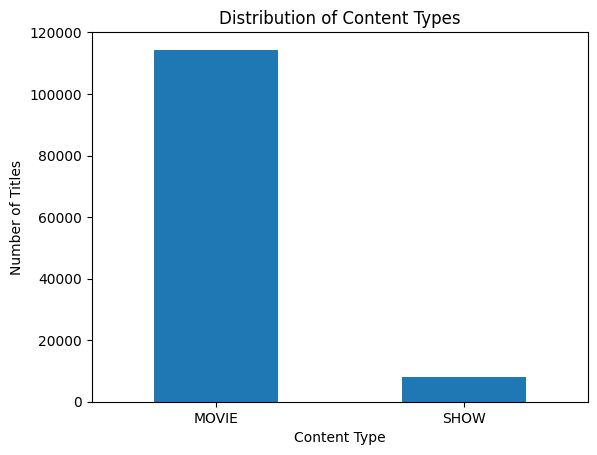

In [46]:
# Bar plot/ count plot on content types to see the distribution over dataset
df['type'].value_counts().plot(kind='bar')
plt.title('Distribution of Content Types')
plt.xlabel('Content Type')
plt.ylabel('Number of Titles')
plt.xticks(rotation=0)
plt.show()

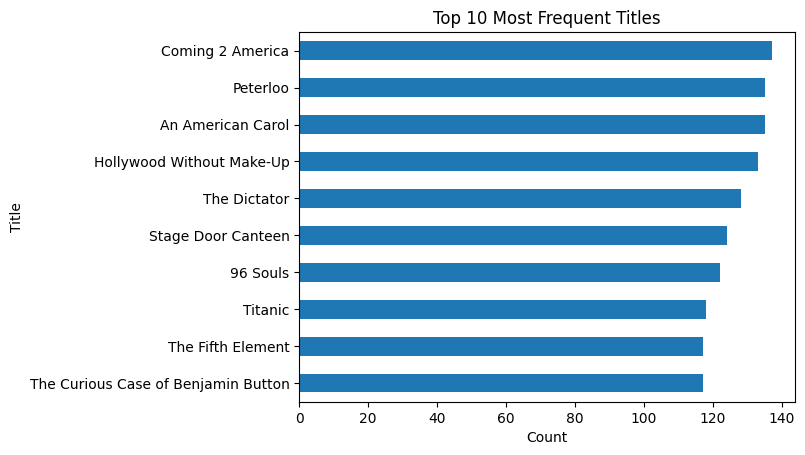

In [47]:
# Bar plot for the frequency of titles
df['title'].value_counts().head(10).sort_values().plot(kind='barh')
plt.title('Top 10 Most Frequent Titles')
plt.xlabel('Count')
plt.ylabel('Title')
plt.show()

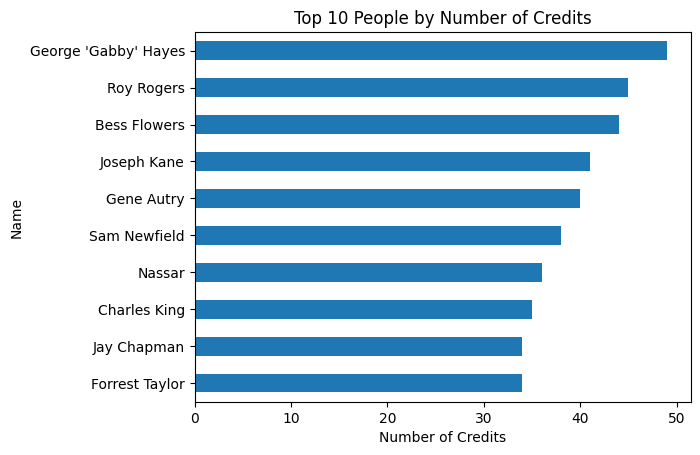

In [48]:
#Bar plot for top credited peoples by frequency
df['name'].value_counts().head(10).sort_values().plot(kind='barh')
plt.title('Top 10 People by Number of Credits')
plt.xlabel('Number of Credits')
plt.ylabel('Name')
plt.show()

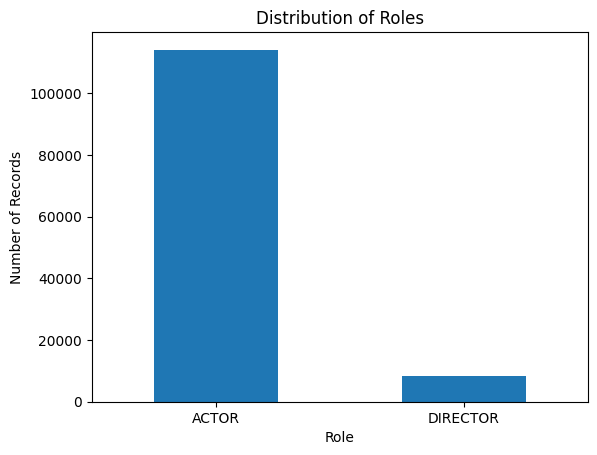

In [49]:
#bar plot to see distribution of roles
df['role'].value_counts().plot(kind='bar')
plt.title('Distribution of Roles')
plt.xlabel('Role')
plt.ylabel('Number of Records')
plt.xticks(rotation=0)
plt.show()

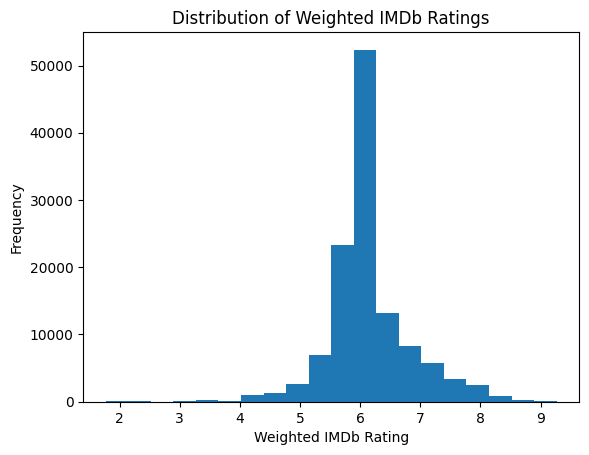

In [50]:
#bar plot to analyse the frequency of imdb ratings
df['weighted_imdb_rating'].plot(kind='hist', bins=20)
plt.title('Distribution of Weighted IMDb Ratings')
plt.xlabel('Weighted IMDb Rating')
plt.ylabel('Frequency')
plt.show()

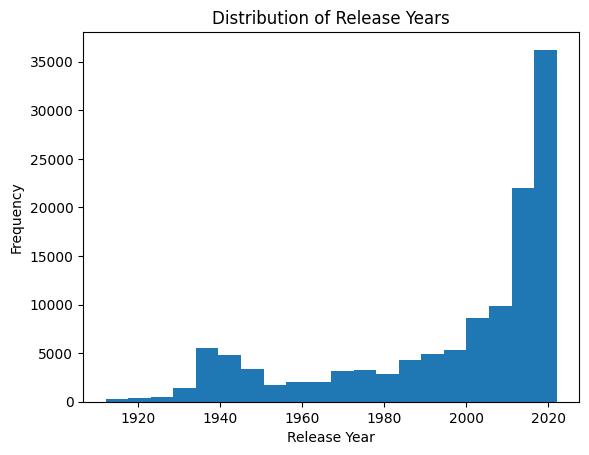

In [51]:
# Bar plot to check distribution over years
df['release_year'].plot(kind='hist', bins=20)
plt.title('Distribution of Release Years')
plt.xlabel('Release Year')
plt.ylabel('Frequency')
plt.show()

## Box plot
### A Box Plot is also known as a Box and Whisker Plot and it is a graphical tool used to understand the distribution of numerical data. It shows the median, quartiles and possible outliers in a simple visual form. It helps compare distributions between groups with ease.

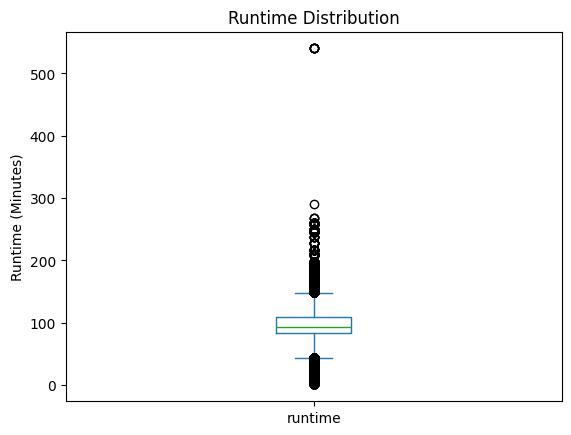

In [52]:
#boxplot to see median, quartiles,outliers and distribution of rutime
df['runtime'].plot(kind='box')
plt.title('Runtime Distribution')
plt.ylabel('Runtime (Minutes)')
plt.show()

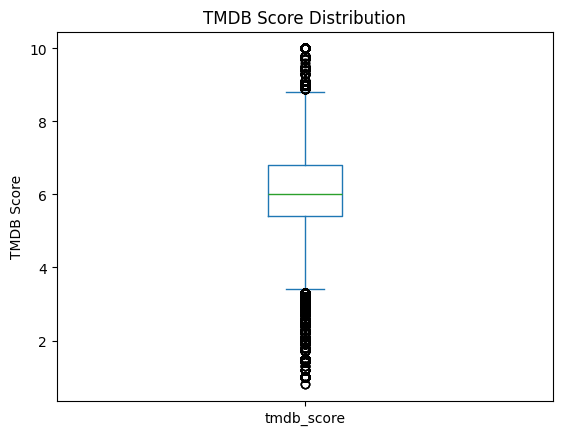

In [53]:
#boxplot to see median, quartiles,outliers and distribution of TMDB score
df['tmdb_score'].plot(kind='box')
plt.title('TMDB Score Distribution')
plt.ylabel('TMDB Score')
plt.show()

## Bivariate Graphs

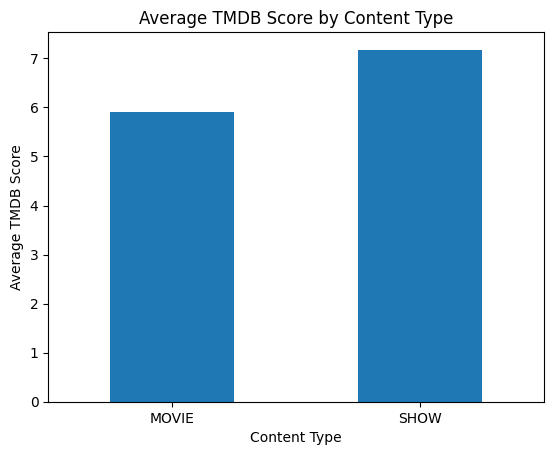

In [54]:
df.groupby('type')['tmdb_score'].mean().sort_values().plot(kind='bar')
plt.title('Average TMDB Score by Content Type')
plt.xlabel('Content Type')
plt.ylabel('Average TMDB Score')
plt.xticks(rotation=0)
plt.show()

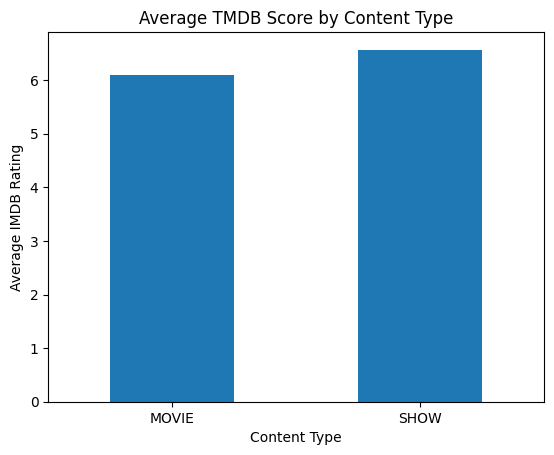

In [55]:
df.groupby('type')['weighted_imdb_rating'].mean().sort_values().plot(kind='bar')
plt.title('Average TMDB Score by Content Type')
plt.xlabel('Content Type')
plt.ylabel('Average IMDB Rating')
plt.xticks(rotation=0)
plt.show()

## **Line graph**
### A line chart is a type of data visualization that displays a series of data points connected by straight line segments to show how a value changes over a continuous progression

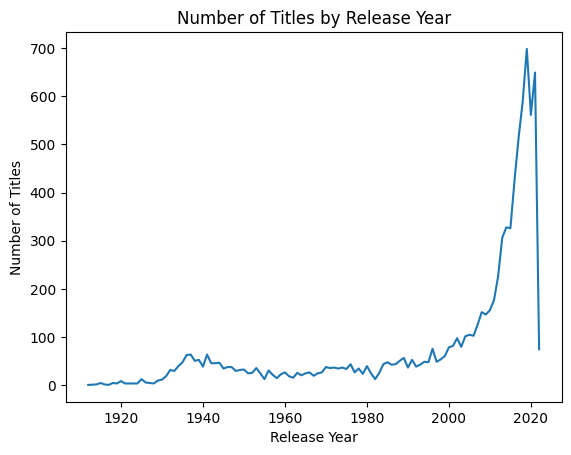

In [56]:
#line graph to study trend over time
df.groupby('release_year')['title'].nunique().plot(kind='line')
plt.title('Number of Titles by Release Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.show()

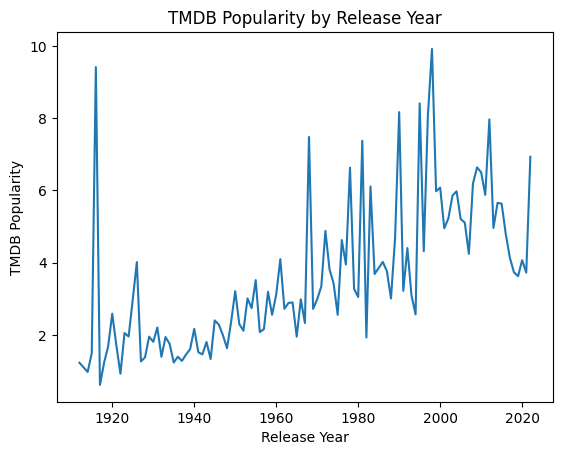

In [57]:
df.groupby('release_year')['tmdb_popularity'].median().plot(kind='line')
plt.title('TMDB Popularity by Release Year')
plt.xlabel('Release Year')
plt.ylabel('TMDB Popularity')
plt.show()

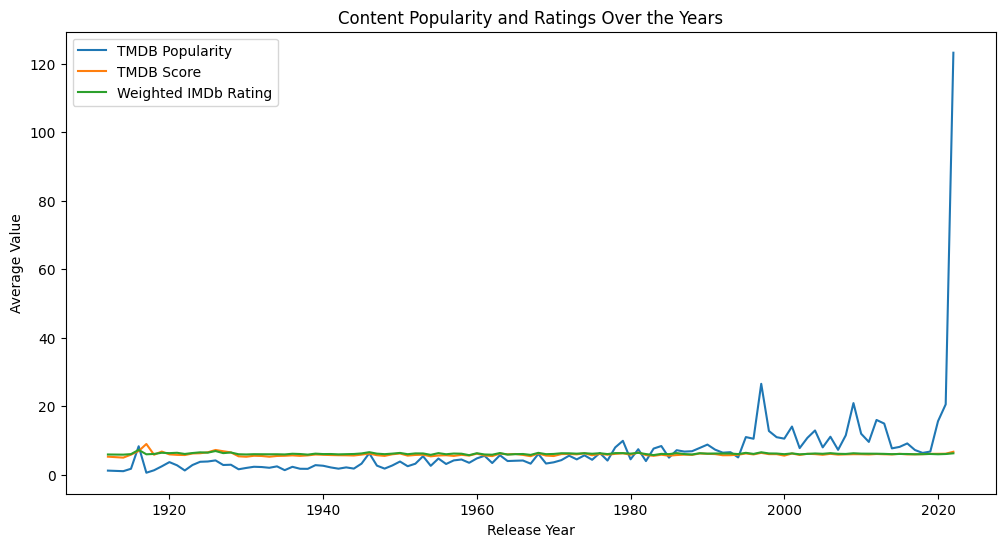

In [58]:
yearly = df.groupby('release_year')[['tmdb_popularity', 'tmdb_score', 'weighted_imdb_rating']].mean()

yearly.plot(figsize=(12,6))
plt.title('Content Popularity and Ratings Over the Years')
plt.xlabel('Release Year')
plt.ylabel('Average Value')
plt.legend(['TMDB Popularity', 'TMDB Score', 'Weighted IMDb Rating'])
plt.show()

## Correlation
### Correlation in data visualization shows how two or more variables relate to each other using graphical formats.

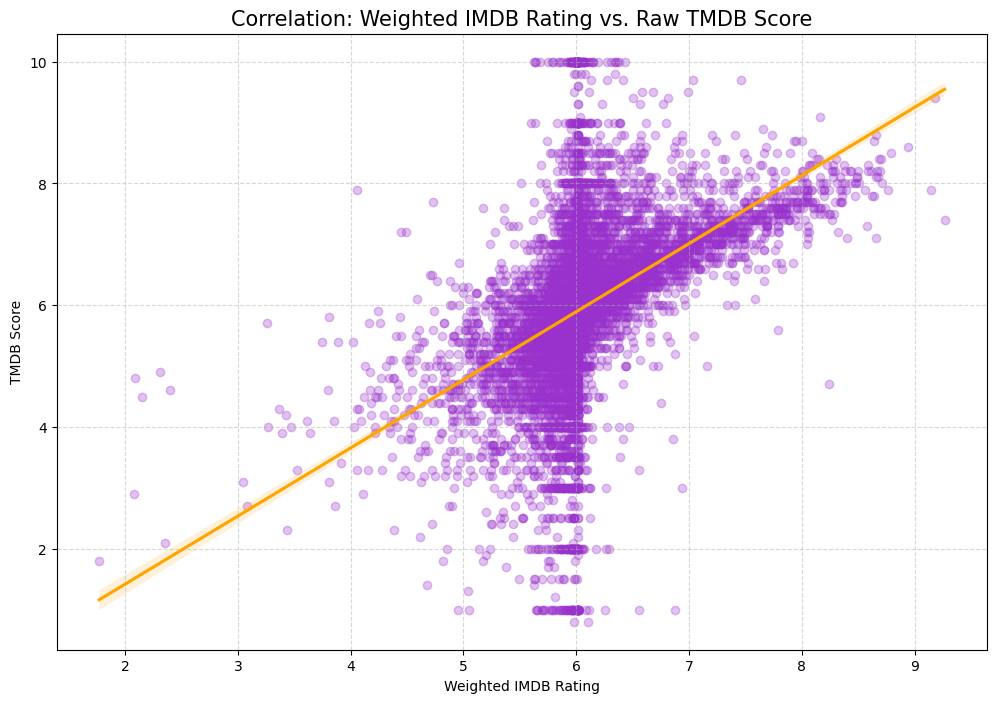

In [59]:
# correlation between imdb rating and tmdb score to study relation between them
comparison_plot_df = df[['title', 'weighted_imdb_rating', 'tmdb_score']].dropna().drop_duplicates('title')

plt.figure(figsize=(12, 8))
sns.regplot(data=comparison_plot_df, x='weighted_imdb_rating', y='tmdb_score',
            scatter_kws={'alpha':0.3, 'color':'darkorchid'}, line_kws={'color':'orange'})

plt.title('Correlation: Weighted IMDB Rating vs. Raw TMDB Score', fontsize=15)
plt.xlabel('Weighted IMDB Rating')
plt.ylabel('TMDB Score')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## KDE PLOT
### A KDE plot (Kernel Density Estimate plot) is a smooth, continuous curve that shows the distribution of a continuous dataset.

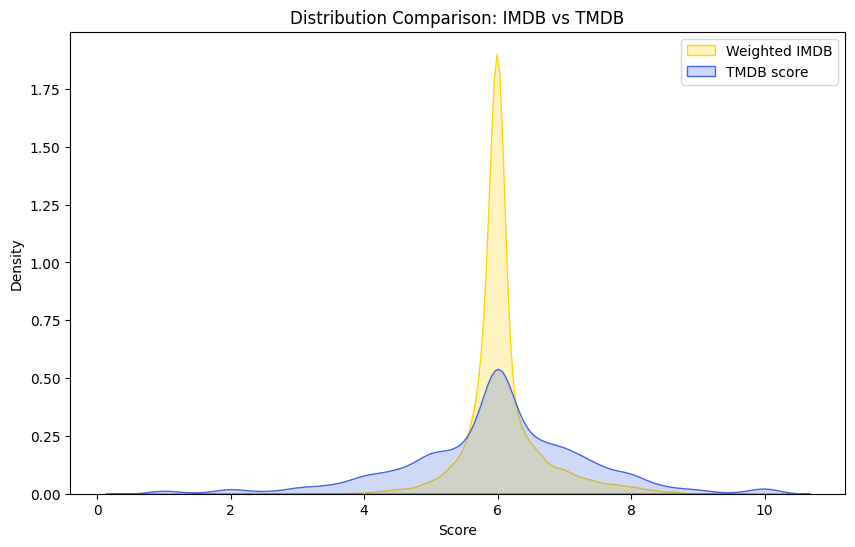

In [60]:
#KDE plot is used to analyze the density distributions of ratings
plt.figure(figsize=(10, 6))
sns.kdeplot(comparison_plot_df['weighted_imdb_rating'], fill=True, label='Weighted IMDB', color='gold')
sns.kdeplot(comparison_plot_df['tmdb_score'], fill=True, label='TMDB score', color='royalblue')

plt.title('Distribution Comparison: IMDB vs TMDB')
plt.xlabel('Score')
plt.ylabel('Density')
plt.legend()
plt.show()

## Multivariate Graph

In [61]:
from ast import literal_eval
df['genres'] = df['genres'].apply(literal_eval)
df_genres_exploded = df.explode('genres')
genre_scores = df_genres_exploded.groupby('genres')[['weighted_imdb_rating', 'tmdb_score']].mean().reset_index()
genre_scores_sorted = genre_scores.sort_values(by='weighted_imdb_rating', ascending=False)

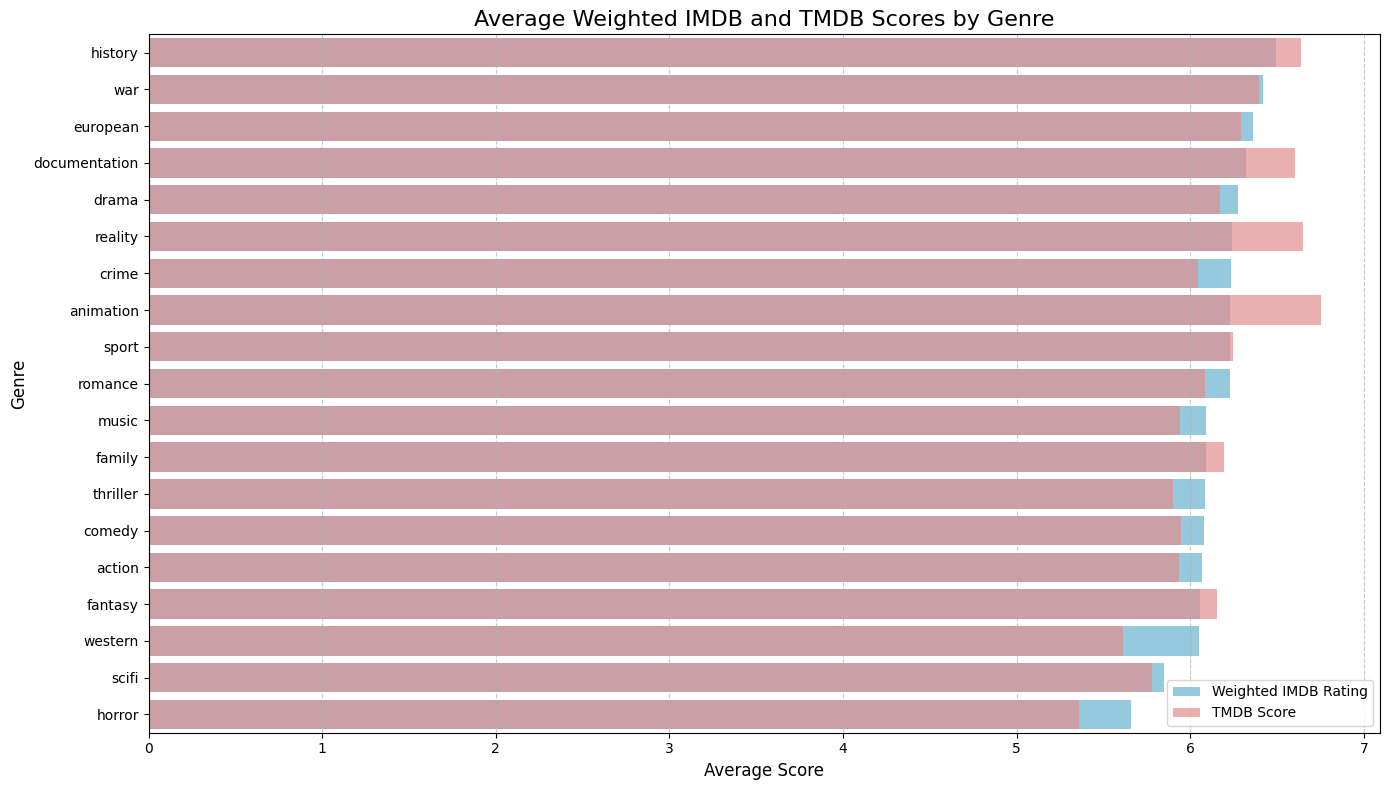

In [62]:
plt.figure(figsize=(14, 8))

sns.barplot(x='weighted_imdb_rating', y='genres', data=genre_scores_sorted, color='skyblue', label='Weighted IMDB Rating')
sns.barplot(x='tmdb_score', y='genres', data=genre_scores_sorted, color='lightcoral', alpha=0.7, label='TMDB Score')

plt.title('Average Weighted IMDB and TMDB Scores by Genre', fontsize=16)
plt.xlabel('Average Score', fontsize=12)
plt.ylabel('Genre', fontsize=12)
plt.legend()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

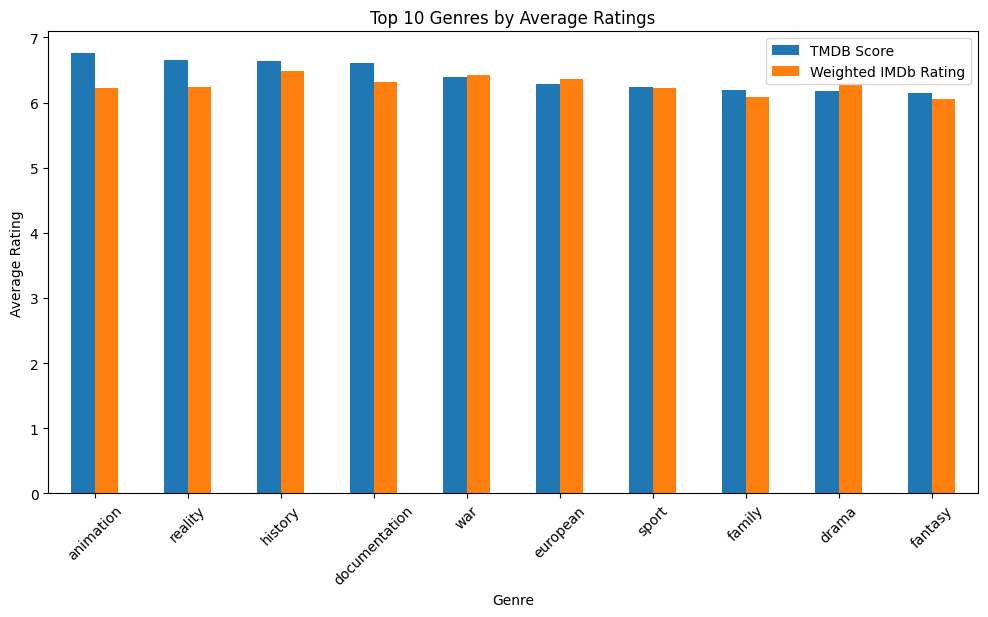

In [63]:
genre_df = df.explode('genres')

genre_scores = genre_df.groupby('genres')[['tmdb_score', 'weighted_imdb_rating']].mean().sort_values('tmdb_score', ascending=False).head(10)

genre_scores.plot(kind='bar', figsize=(12,6))
plt.title('Top 10 Genres by Average Ratings')
plt.xlabel('Genre')
plt.ylabel('Average Rating')
plt.xticks(rotation=45)
plt.legend(['TMDB Score', 'Weighted IMDb Rating'])
plt.show()

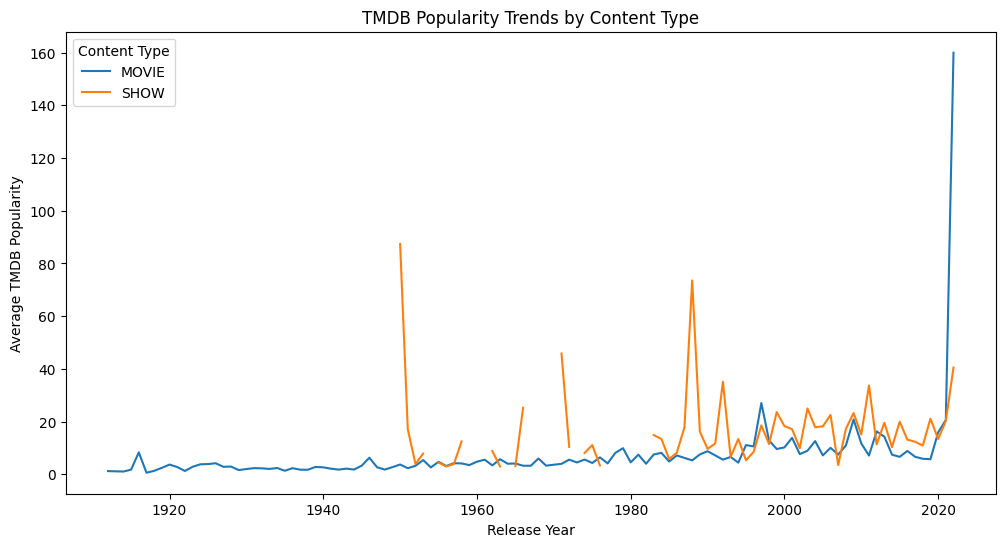

In [64]:
year_type = df.groupby(['release_year', 'type'])['tmdb_popularity'].mean().unstack()

year_type.plot(figsize=(12,6))
plt.title('TMDB Popularity Trends by Content Type')
plt.xlabel('Release Year')
plt.ylabel('Average TMDB Popularity')
plt.legend(title='Content Type')
plt.show()

## Heatmap
### A heatmap (or heat map) is a popular data visualization technique that uses color gradients to represent the magnitude, density, or frequency of data values within a two-dimensional grid or matrix

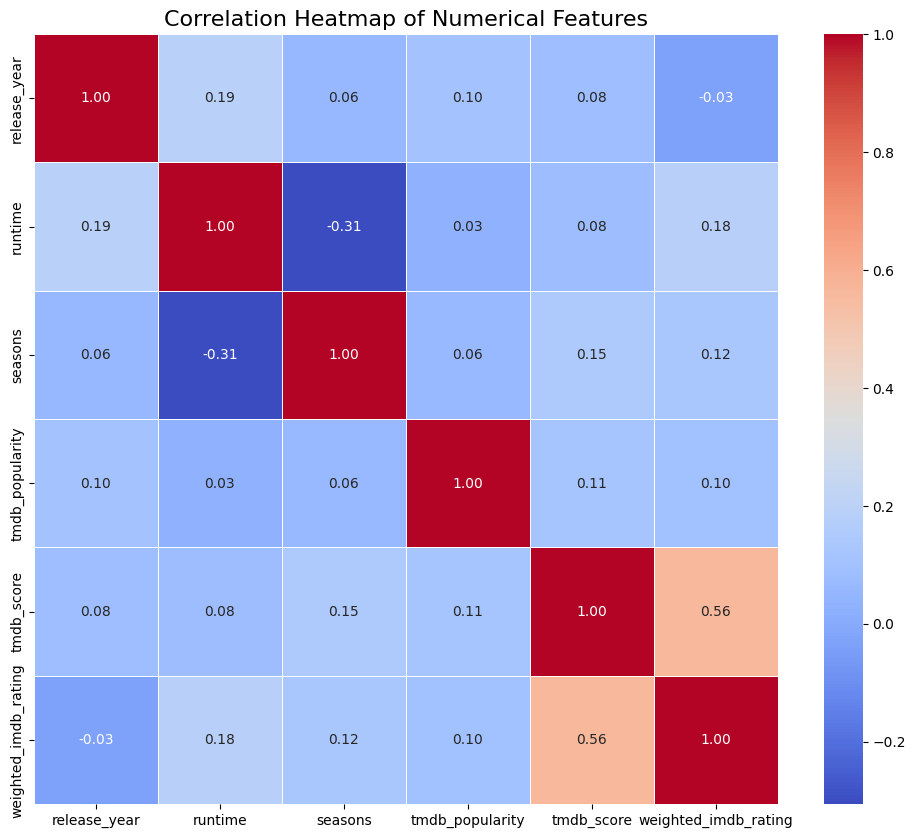

In [65]:
#heatmap to study the correlation of numerical columns with each other
numerical_cols = [ 'release_year', 'runtime', 'seasons', 'tmdb_popularity', 'tmdb_score', 'weighted_imdb_rating']
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Numerical Features', fontsize=16)
plt.show()

# Conclusion

This Exploratory Data Analysis (EDA) of the Amazon Prime Video dataset provides useful insights into the platform's content portfolio, audience ratings, popularity, and content trends.

- Amazon Prime's catalog is strongly concentrated in **Movies**, indicating that movies form a major part of the platform's content strategy.

- **Drama, Comedy, Thriller, Action, and Romance** are among the prominent genres, showing a broad content portfolio with strong representation across popular categories.

- The number of titles has increased substantially in recent release years, indicating a growing focus on **newer content** while maintaining a diverse historical catalog.

- **TMDB Popularity varies considerably across titles**, suggesting that audience attention is concentrated on a relatively smaller group of highly visible content.

- **TMDB Score and Weighted IMDb Rating** provide useful measures of content quality, and their relationship indicates that highly rated titles generally receive stronger quality signals across both platforms.

- The comparison of **release year and TMDB popularity** shows that content popularity changes over time, making release period an important factor when evaluating catalog performance.

- Genre-level comparison of **TMDB Score and Weighted IMDb Rating** shows that content quality differs across genres, providing useful direction for genre-level content decisions.

- The analysis of **content type, ratings, and popularity together** shows that catalog size alone is not enough to evaluate content performance; quality and audience interest should also be considered.

Overall, the analysis can help Amazon identify **high-quality and high-interest content, understand genre opportunities, evaluate content trends, and make more informed content acquisition and promotional decisions**.